## Analyse exploratoire des données(EDA)

In [31]:
import pandas as pd

data = pd.read_csv("marketing_campaign_EDA.csv")
data.head()

,Income,Recency,NumWebVisitsMonth,Education_encoded,Marital_Status_encoded,Age,Seniority,TotalMnt,TotalPurchases,TotalChildren,SpendPerIncome
0,58138.0,58,7,3,1.0,69,165,1617,25,0,0.027813
1,46344.0,38,5,3,1.0,72,147,27,6,2,0.000583
2,71613.0,26,4,3,2.0,61,153,776,21,0,0.010836
3,26646.0,26,6,3,2.0,42,147,53,8,1,0.001989
4,58293.0,94,5,5,3.0,45,148,422,19,1,0.007239


# Analyse statistique

In [34]:
data.describe()

,Income,Recency,NumWebVisitsMonth,Education_encoded,Marital_Status_encoded,Age,Seniority,TotalMnt,TotalPurchases,TotalChildren,SpendPerIncome
count,2216.000000,2216.000000,2216.000000,2216.000000,2213.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,49.012635,5.319043,3.459838,2.483507,57.179603,154.637184,607.075361,14.880866,0.947202,0.009911
std,25173.076661,28.948352,2.425359,1.004825,1.049982,11.985554,6.766012,602.900476,7.670957,0.749062,0.016811
min,1730.000000,0.000000,0.000000,1.000000,0.000000,30.000000,143.000000,5.000000,0.000000,0.000000,0.000039
25%,35303.000000,24.000000,3.000000,3.000000,2.000000,49.000000,149.000000,69.000000,8.000000,0.000000,0.002345
50%,51381.500000,49.000000,6.000000,3.000000,3.000000,56.000000,155.000000,396.500000,15.000000,1.000000,0.008005
75%,68522.000000,74.000000,7.000000,4.000000,3.000000,67.000000,160.000000,1048.000000,21.000000,1.000000,0.015533
max,666666.000000,99.000000,20.000000,5.000000,5.000000,133.000000,166.000000,2525.000000,44.000000,3.000000,0.706699


# Analyse univariée

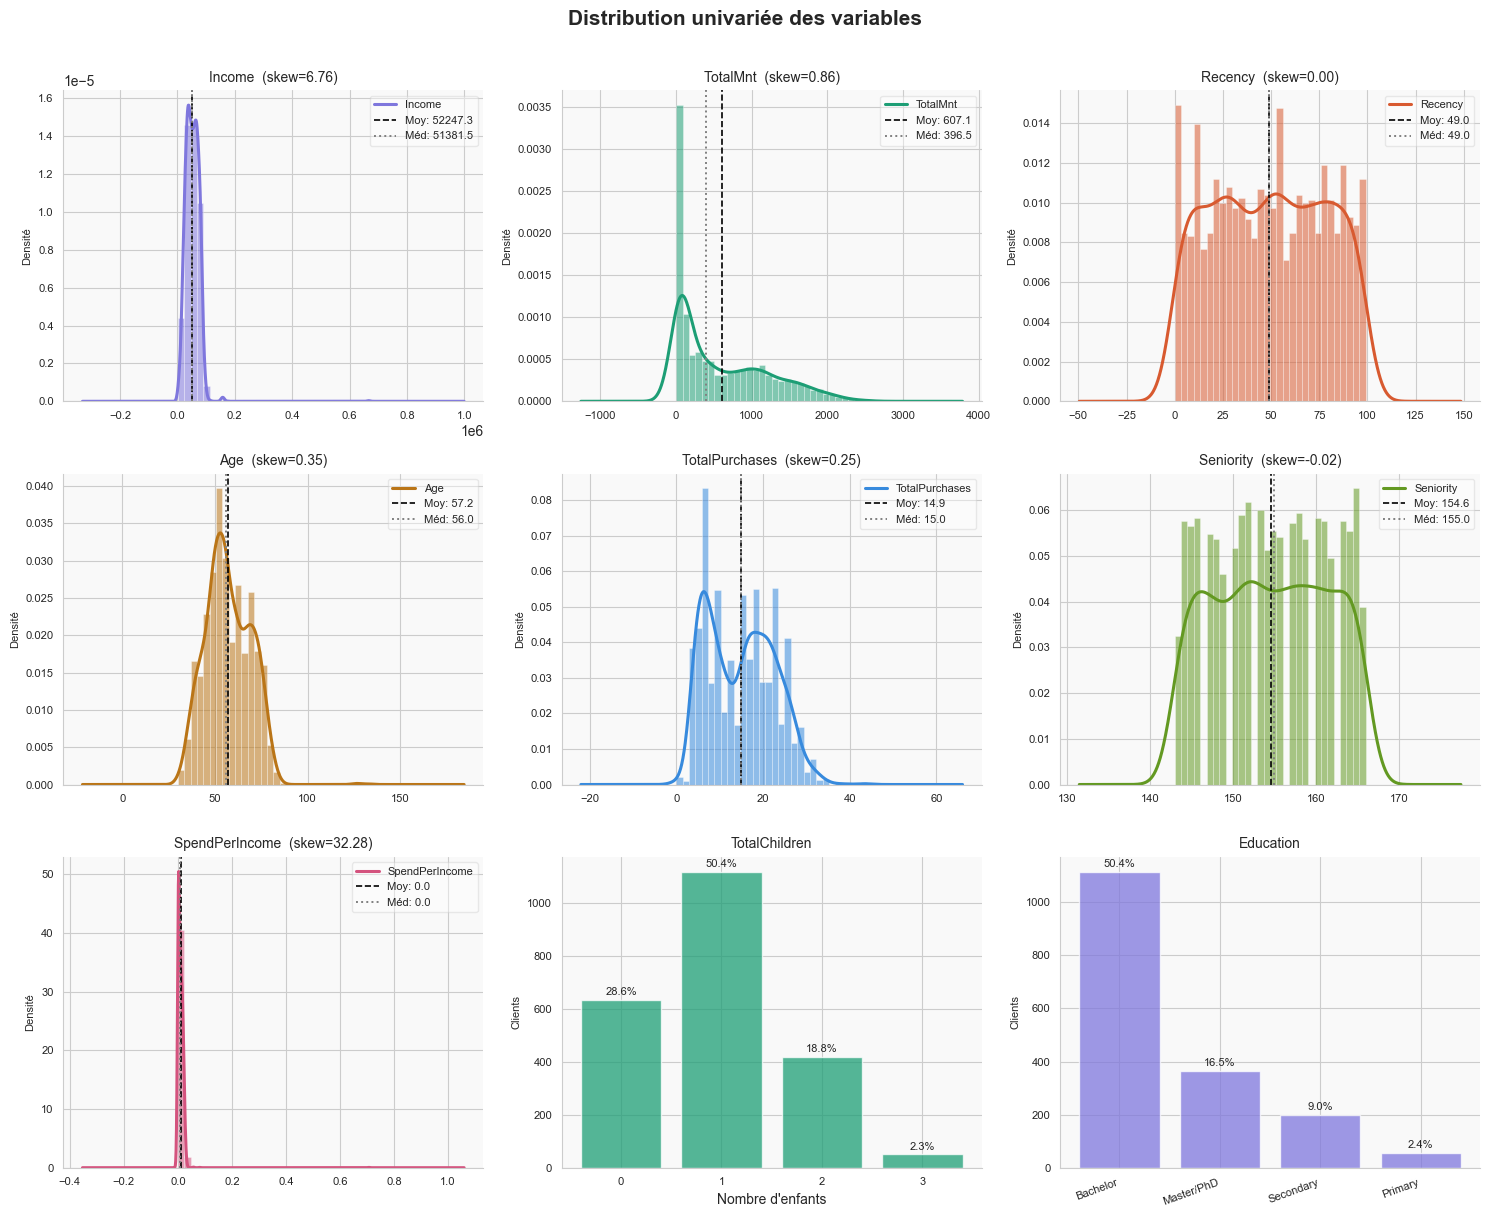

Figure sauvegardée : distributions_univariees.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

mapping = {
    1: "Primary",
    2: "Secondary",
    3: "Bachelor",
    4: "Master/PhD"
}

education_labels = data['Education_encoded'].map(mapping)
data['education_labels'] = data['Education_encoded'].map(mapping)

NUM_VARS = ["Income", "TotalMnt", "Recency", "Age",
            "TotalPurchases", "Seniority", "SpendPerIncome"]
 
CAT_VARS = ["TotalChildren","education_labels"]
COLORS = {
    "Income":         "#7F77DD",
    "TotalMnt":       "#1D9E75",
    "Recency":        "#D85A30",
    "Age":            "#BA7517",
    "TotalPurchases": "#378ADD",
    "Seniority":      "#639922",
    "SpendPerIncome": "#D4537E",
    "TotalChildren":  "#1D9E75",
    "education_labels":"#7F77DD",
}
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Distribution univariée des variables", fontsize=15, fontweight="bold", y=1.01)
 
sns.set_style("whitegrid")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
 
all_vars = NUM_VARS + CAT_VARS  # 9 variables
 
for ax, var in zip(axes.flat, all_vars):
    color = COLORS[var]
 
    if var in NUM_VARS:
        series = data[var].dropna()
        ax.hist(series, bins=30, color=color, alpha=0.55,
                edgecolor="white", linewidth=0.4, density=True)
        series.plot.kde(ax=ax, color=color, linewidth=2.2)
        ax.axvline(series.mean(),   color="black", linestyle="--",
                   linewidth=1.2, label=f"Moy: {series.mean():.1f}")
        ax.axvline(series.median(), color="gray",  linestyle=":",
                   linewidth=1.4, label=f"Méd: {series.median():.1f}")
        ax.legend(fontsize=8, framealpha=0.4)
        ax.set_title(f"{var}  (skew={series.skew():.2f})", fontsize=10, fontweight="500")
 
    elif var == "TotalChildren":
        counts = data[var].value_counts().sort_index()
        bars = ax.bar(counts.index.astype(str), counts.values,
                      color=color, alpha=0.75, edgecolor="white")
        for bar in bars:
            pct = bar.get_height() / len(data) * 100
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + len(data)*0.005,
                    f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
        ax.set_title("TotalChildren", fontsize=10, fontweight="500")
        ax.set_xlabel("Nombre d'enfants")
 
    elif var == "education_labels":
        order = data[var].value_counts().index
        counts = data[var].value_counts()
        bars = ax.bar(range(len(order)), counts.values,
                      color=color, alpha=0.75, edgecolor="white")
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=20, ha="right", fontsize=8)
        for bar in bars:
            pct = bar.get_height() / len(data) * 100
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + len(data)*0.005,
                    f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
        ax.set_title("Education", fontsize=10, fontweight="500")
 
    ax.set_ylabel("Densité" if var in NUM_VARS else "Clients", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_facecolor("#f9f9f9")
 
plt.tight_layout()
plt.savefig("distributions_univariees.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : distributions_univariees.png")


# Analyse bivariée